# Session 1

## Task 1 

In [1]:
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib

print('Seaborn version:', sns.__version__)
print('Matplotlib version:', matplotlib.__version__)

Seaborn version: 0.13.2
Matplotlib version: 3.10.8


*(This notebook is named `seaborn_intro.ipynb` as the task specifies — see the filename it was saved with.)*

## Task 2 — Weekly Temperature Trend with sns.lineplot()

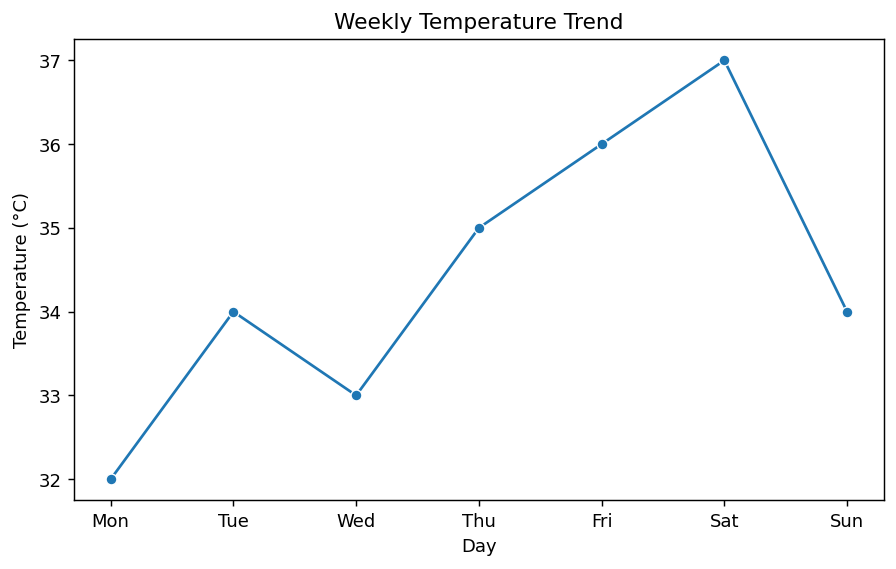

In [1]:
days = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
temps = [32, 34, 33, 35, 36, 37, 34]

plt.figure(figsize=(7, 4.5))
sns.lineplot(x=days, y=temps, marker='o')
plt.xlabel('Day')
plt.ylabel('Temperature (°C)')
plt.title('Weekly Temperature Trend')
plt.tight_layout()
plt.show()

## Task 3 — Axes-Level vs Figure-Level: lineplot() vs relplot()

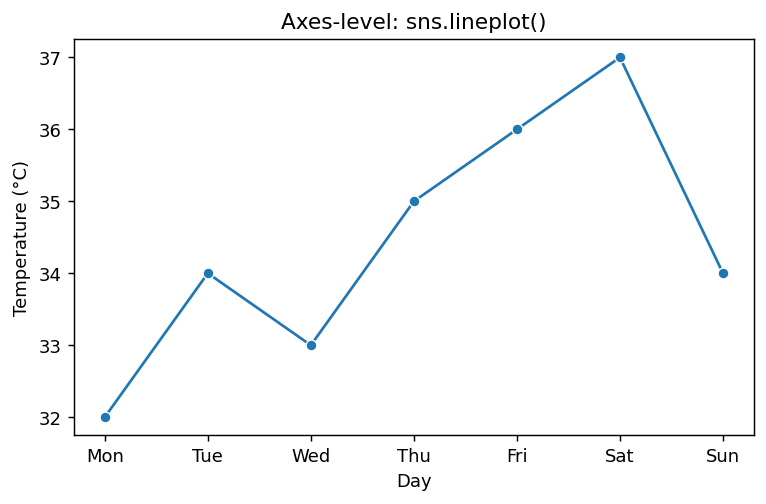

In [1]:
# Axes-level: sns.lineplot() draws onto an existing/current Axes
fig, ax = plt.subplots(figsize=(6, 4))
sns.lineplot(x=days, y=temps, marker='o', ax=ax)
ax.set_xlabel('Day')
ax.set_ylabel('Temperature (°C)')
ax.set_title('Axes-level: sns.lineplot()')
plt.tight_layout()
plt.show()

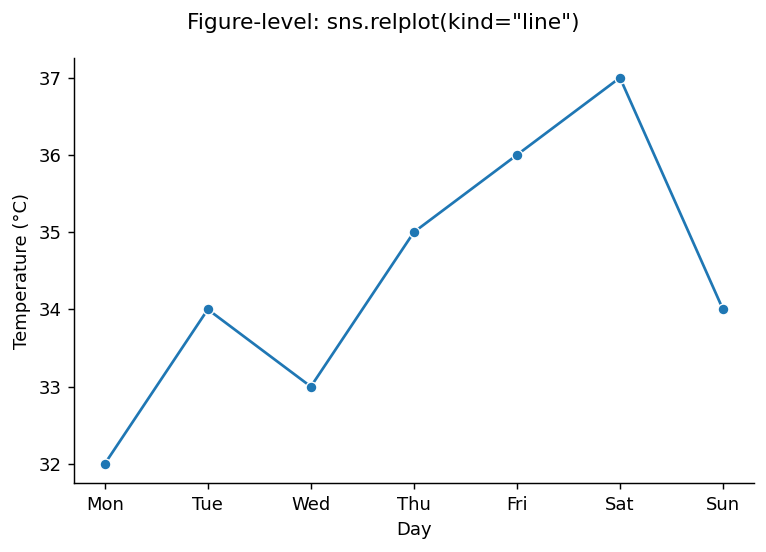

In [1]:
# Figure-level: sns.relplot() creates its own Figure + FacetGrid and returns that, not an Axes
g = sns.relplot(x=days, y=temps, kind='line', marker='o', height=4, aspect=1.5)
g.set_axis_labels('Day', 'Temperature (°C)')
g.figure.suptitle('Figure-level: sns.relplot(kind="line")', y=1.05)
plt.show()

**Difference observed:** `sns.lineplot()` (axes-level) draws onto a single Matplotlib `Axes` you control directly — it plugs into `plt.subplots()` layouts and existing figures. `sns.relplot()` (figure-level) creates and owns its *entire* Figure (via a `FacetGrid`), which is what gives it faceting abilities (`col=`, `row=`) that `lineplot()` doesn't have on its own — but it can't just be dropped into an existing subplot grid the way `lineplot()` can.

## Task 4 — Applying the Three Built-in Themes

Saved: ['temp_trend_darkgrid.png', 'temp_trend_whitegrid.png', 'temp_trend_ticks.png']


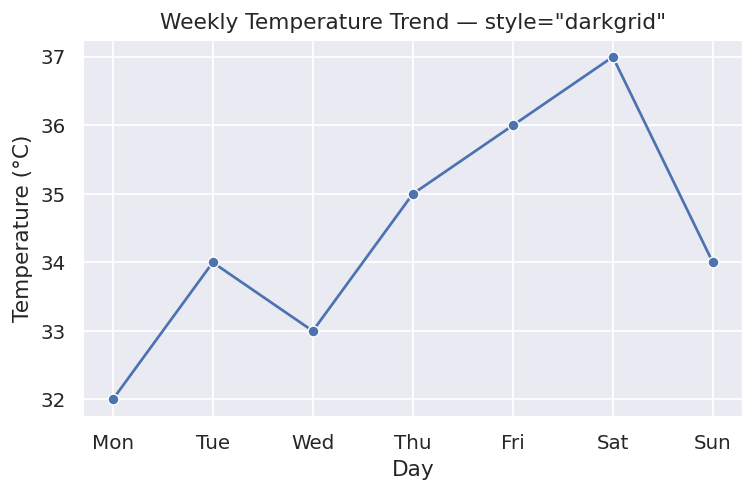

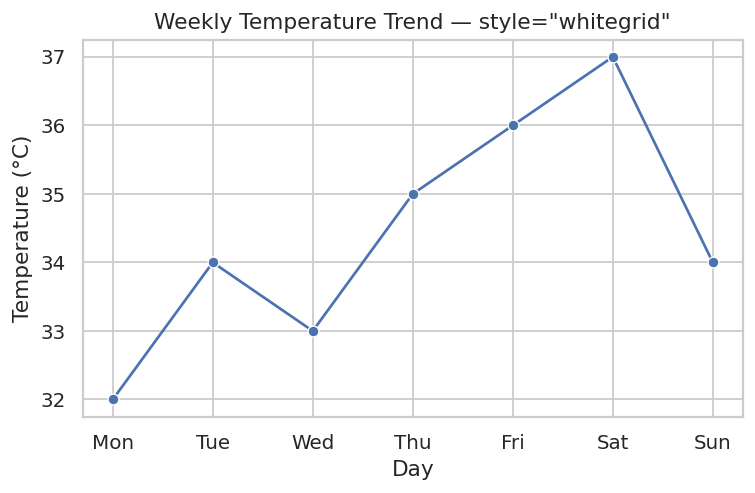

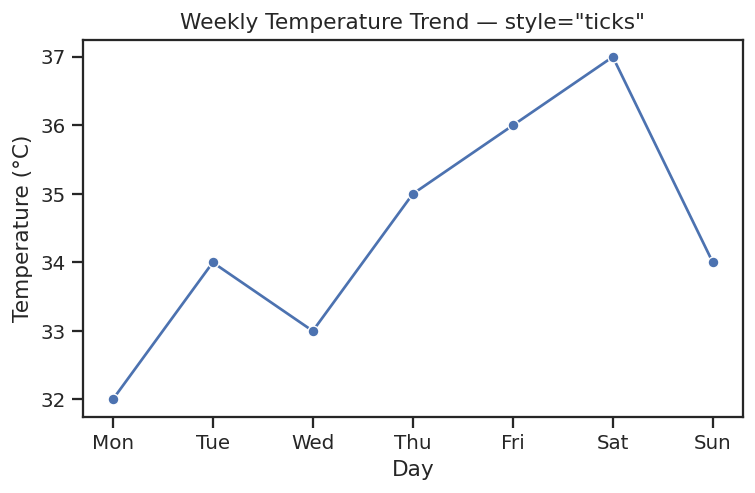

In [1]:
import os
os.makedirs('theme_exports', exist_ok=True)

themes = ['darkgrid', 'whitegrid', 'ticks']
for theme in themes:
    sns.set_theme(style=theme)
    plt.figure(figsize=(6, 4))
    sns.lineplot(x=days, y=temps, marker='o')
    plt.xlabel('Day')
    plt.ylabel('Temperature (°C)')
    plt.title(f'Weekly Temperature Trend — style="{theme}"')
    plt.tight_layout()
    plt.savefig(f'theme_exports/temp_trend_{theme}.png', dpi=150)
    plt.show()

sns.set_theme(style='darkgrid')  # reset to a sensible default
print('Saved:', [f'temp_trend_{t}.png' for t in themes])

**Comparison:** `darkgrid` (the seaborn default) uses a light-gray background with solid white gridlines — good general-purpose readability. `whitegrid` keeps a white background but adds visible gridlines, which suits plots with lots of categorical bars where a busy gray background would compete for attention. `ticks` drops the grid entirely and adds small axis tick marks instead — cleanest look, best when the exact values matter less than the overall trend shape.